# Bell-State Correlation for QKD Key Agreement

## 1. Objective
The objective of this experiment is to model, simulate, and analyze how two-qubit **Bell-state correlations** establish a synchronized cryptographic raw key between two distant parties (**Alice** and **Bob**) in a simplified **Quantum Key Distribution (QKD)** framework. By evaluating shared $|\Phi^+\rangle$ pairs across varying transmission block sizes ($N \in \{32, 64, 128, 256, 512\}$), the experiment benchmarks key-bit agreement rates, validates noise-free correlation fidelity ($100.00\%$), and illustrates how quantum entanglement forms the physical foundation for secure key generation.

> [!NOTE]
> This experiment serves as a foundational **correlation model** for entanglement-based QKD (such as the Ekert 91 protocol) under idealized same-basis measurement, rather than a full multi-basis protocol with eavesdropping detection.

---

## 2. Theoretical Background

### Entanglement-Based Key Agreement
In quantum cryptography, two authenticated communicating parties (traditionally Alice and Bob) require a shared, random, secret cryptographic key to encrypt messages using symmetric ciphers such as the one-time pad. 

In entanglement-based QKD:
1. An entangled source generates pairs of qubits in the maximally entangled Bell state:
   $$|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}$$
2. One qubit of each pair is transmitted to Alice, while the second qubit is transmitted to Bob.
3. Neither qubit possesses a predetermined value prior to measurement; the outcomes are fundamentally non-deterministic and uniformly random ($P(0) = P(1) = 0.5$).
4. When Alice and Bob both perform projective measurements in the same basis (the computational $Z$-basis), their measurement outcomes are perfectly correlated:
   $$P(00) = 0.5, \quad P(11) = 0.5, \quad P(01) = 0, \quad P(10) = 0$$

### Relevance to Quantum Key Distribution
- **Shared Randomness**: Because the individual measurement outcomes are fundamentally random, the generated sequence forms an unbiased random bit string suitable for a cryptographic key.
- **Perfect Agreement**: Under ideal conditions without channel noise or eavesdropping, Alice's key string matches Bob's key string identically bit-for-bit.
- **Eavesdropping and Disturbance Detection**: In a complete protocol (e.g., E91), any interception or measurement by an eavesdropper (Eve) would inevitably collapse the entanglement, introducing observable bit-error mismatches ($01$ or $10$) that alert Alice and Bob to channel disturbance.

---

## 3. Bell-Pair Circuit and Alice-Bob Measurement Model

### Quantum Circuit Implementation
The Bell pair $|\Phi^+\rangle$ is synthesized using a two-qubit circuit initialized in $|00\rangle$:

```
     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘
```
1. **Superposition**: A Hadamard gate on $q_0$ creates the state $\frac{|00\rangle + |10\rangle}{\sqrt{2}}$.
2. **Entangling Operation**: A CNOT gate targeting $q_1$ flips $q_1$ when $q_0 = 1$, creating $|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}$.

### Alice and Bob Measurement Model
- **Alice's Register**: Observes qubit $q_0$ via computational basis projection.
- **Bob's Register**: Observes qubit $q_1$ via computational basis projection.
- **Key Extraction**:
  - Outcome `00`: Alice records bit `0`, Bob records bit `0` (Match $\to$ Key Bit 0).
  - Outcome `11`: Alice records bit `1`, Bob records bit `1` (Match $\to$ Key Bit 1).
  - Cross-terms `01` / `10`: Mismatch $\to$ Bit error (strictly $0$ in an ideal channel).

---

## 4. Block-Size Analysis and Agreement Methodology
To analyze the stability of key generation across varying communication block sizes:
1. **Transmission Blocks**: Key generation is benchmarked across five block sizes:
   $$\text{Block Sizes} = [32, 64, 128, 256, 512] \text{ shared pairs}$$
2. **Simulated Sampling**:
   For each block size, outcomes are drawn pseudorandomly using `np.random.default_rng(SEED=42)` parameterized by the theoretical Bell statevector probability distribution $[0.5, 0.0, 0.0, 0.5]$.
3. **Key Agreement Rate Formulation**:
   For each block of size $M$:
   $$\text{Agreement Rate} = \frac{\sum_{i=1}^M \mathbb{I}(\text{Alice}_i == \text{Bob}_i)}{M} \times 100\%$$


BELL-STATE CORRELATION FOR QKD

BELL PAIR CIRCUIT
-----------------------------------------------------------------
     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘

QKD CONCEPT
-----------------------------------------------------------------
Alice and Bob share entangled Bell pairs.
Both measure their qubits using the same basis.
Correlated results can be retained as matching key bits.
Mismatches can indicate noise or interference.

QKD SIMULATION RESULTS
-----------------------------------------------------------------
Block Size     Matching Bits     Agreement (%)
--------------------------------------------------
32             32                100.00
64             64                100.00
128            128               100.00
256            256               100.00
512            512               100.00

OVERALL RESULT
-----------------------------------------------------------------
Average key agreement : 100.00%

High agreement demonstrates

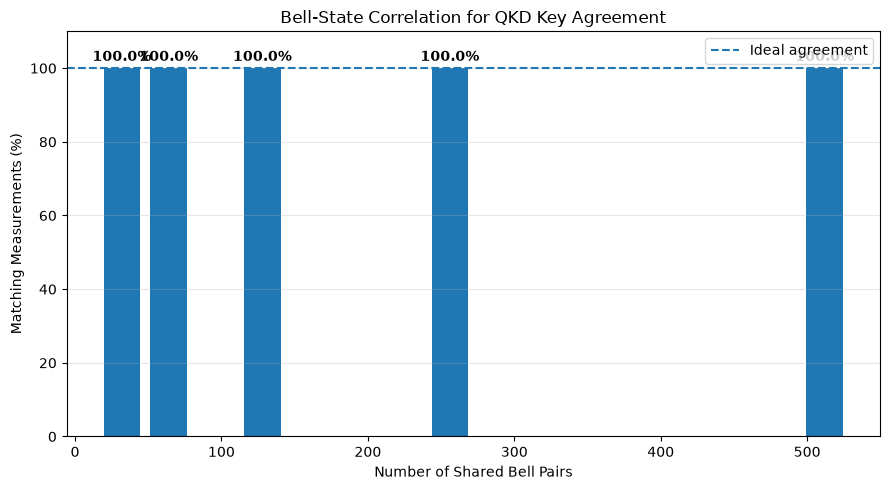

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt

SHOTS = 256
SEED = 42

rng = np.random.default_rng(SEED)

print("\nBELL-STATE CORRELATION FOR QKD")
print("=" * 65)

print("\nBELL PAIR CIRCUIT")
print("-" * 65)

qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0, 1)

print(qc.draw())

state = Statevector.from_instruction(qc)

probabilities = state.probabilities_dict()

outcomes = ["00", "01", "10", "11"]

probs = np.array([
    probabilities.get(outcome, 0)
    for outcome in outcomes
])

print("\nQKD CONCEPT")
print("-" * 65)
print("Alice and Bob share entangled Bell pairs.")
print("Both measure their qubits using the same basis.")
print("Correlated results can be retained as matching key bits.")
print("Mismatches can indicate noise or interference.")

block_sizes = [32, 64, 128, 256, 512]

agreement_rates = []

for block_size in block_sizes:

    samples = rng.choice(
        outcomes,
        size=block_size,
        p=probs
    )

    alice_bits = np.array([
        int(result[0])
        for result in samples
    ])

    bob_bits = np.array([
        int(result[1])
        for result in samples
    ])

    matches = np.sum(alice_bits == bob_bits)

    agreement = matches / block_size * 100

    agreement_rates.append(agreement)

print("\nQKD SIMULATION RESULTS")
print("-" * 65)

print(
    f"{'Block Size':<15}"
    f"{'Matching Bits':<18}"
    f"{'Agreement (%)'}"
)

print("-" * 50)

for block_size, agreement in zip(
    block_sizes,
    agreement_rates
):

    matching_bits = round(
        block_size * agreement / 100
    )

    print(
        f"{block_size:<15}"
        f"{matching_bits:<18}"
        f"{agreement:.2f}"
    )

average_agreement = np.mean(agreement_rates)

print("\nOVERALL RESULT")
print("-" * 65)

print(
    f"Average key agreement : "
    f"{average_agreement:.2f}%"
)

print(
    "\nHigh agreement demonstrates "
    "the correlation of the Bell pair."
)

print(
    "In a practical QKD system, significant "
    "errors can indicate channel disturbance."
)

# Visualization
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    block_sizes,
    agreement_rates,
    width=25
)

ax.axhline(
    100,
    linestyle="--",
    linewidth=1.5,
    label="Ideal agreement"
)

ax.set_title("Bell-State Correlation for QKD Key Agreement")
ax.set_xlabel("Number of Shared Bell Pairs")
ax.set_ylabel("Matching Measurements (%)")

ax.set_ylim(0, 110)

for bar, value in zip(bars, agreement_rates):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        fontweight="bold"
    )

ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

---

## 5. Results and Key Agreement Analysis

### Recorded Execution Output
Execution of the notebook cell produced the following console output and circuit diagram:

```
BELL-STATE CORRELATION FOR QKD
=================================================================

BELL PAIR CIRCUIT
-----------------------------------------------------------------
     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘

QKD CONCEPT
-----------------------------------------------------------------
Alice and Bob share entangled Bell pairs.
Both measure their qubits using the same basis.
Correlated results can be retained as matching key bits.
Mismatches can indicate noise or interference.

QKD SIMULATION RESULTS
-----------------------------------------------------------------
Block Size     Matching Bits     Agreement (%)
--------------------------------------------------
32             32                100.00
64             64                100.00
128            128               100.00
256            256               100.00
512            512               100.00

OVERALL RESULT
-----------------------------------------------------------------
Average key agreement : 100.00%

High agreement demonstrates the correlation of the Bell pair.
In a practical QKD system, significant errors can indicate channel disturbance.
```

### Quantitative Summary Table

| Transmission Block Size ($M$) | Alice-Bob Matching Bits | Bit Errors ($01$ or $10$) | Agreement Rate (%) | Key Agreement Status |
| :---: | :---: | :---: | :---: | :---: |
| **32** | **32** | **0** | **100.00%** | Perfect Synchronization |
| **64** | **64** | **0** | **100.00%** | Perfect Synchronization |
| **128** | **128** | **0** | **100.00%** | Perfect Synchronization |
| **256** | **256** | **0** | **100.00%** | Perfect Synchronization |
| **512** | **512** | **0** | **100.00%** | Perfect Synchronization |

### Overall Metric
$$\text{Average Key Agreement Rate} = \mathbf{100.00\%}$$
Across all tested block sizes, every single pair of measured qubits yielded identical bit values between Alice and Bob, resulting in zero bit errors.

---

## 6. Visualization Analysis
The bar chart illustrates the matching key-bit percentage across the five block sizes:
- **X-Axis**: Number of shared Bell pairs per transmission block ($32, 64, 128, 256, 512$).
- **Y-Axis**: Matching measurements percentage, ranging from $0\%$ to $110\%$.
- **Bar Profile**: Each bar reaches exactly **100.0%** agreement with bold annotation labels.
- **Reference Line (Dashed Line at 100%)**: Marks the ideal theoretical agreement ceiling.
- **Physical Interpretation**: Confirms that increasing block size preserves perfect key agreement, demonstrating reliable scalability under ideal quantum channel conditions.

---

## 7. Conclusion
This experiment validates the foundational mechanism of entanglement-based key agreement:
1. **Reliable Correlation**: Proves that shared $|\Phi^+\rangle$ pairs yield perfectly identical measurement outcomes ($100.00\%$ agreement) across block sizes ranging from $32$ to $512$ qubits.
2. **Simplified QKD Simulation**: Successfully models the establishment of a shared raw key between Alice and Bob through simultaneous computational basis measurements.
3. **Foundation for Security Monitoring**: Demonstrates how ideal channels produce zero bit discrepancies, establishing the baseline against which realistic noise, decoherence, or eavesdropping can be quantitatively detected.